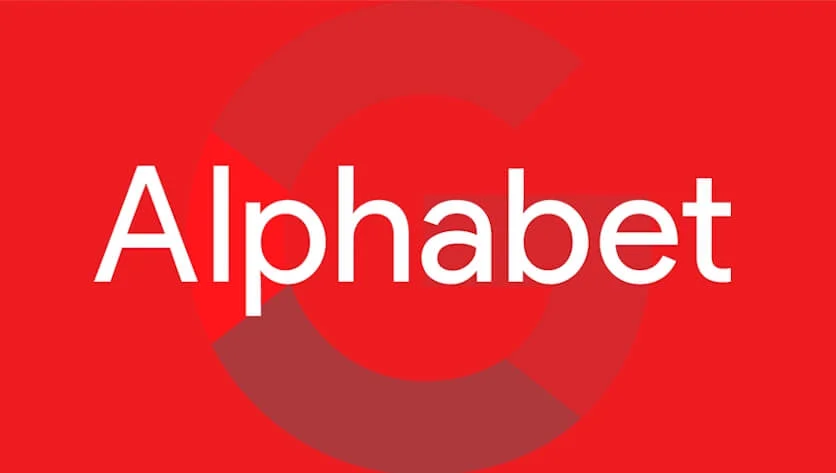

## ***Alphabet Inc.***

**알파벳(Alphabet Inc.)**은 구글(Google)의 모회사인 미국의 다국적 기업입니다. 이 회사는 1998년 래리 페이지(Larry Page)와 세르게이 브린(Sergey Brin)에 의해 설립되었으며, 2015년 구글이 재편성되어 알파벳이라는 새로운 지주 회사의 자회사가 되었습니다.


***알파벳(Alphabet Inc.)에 대한 주요 정보:***

- 티커: GOOGL (주주총회에서 의결권을 가진 A주)
- 본사 위치: 미국 캘리포니아 주 마운틴 뷰(Mountain View)
- 주요 사업: 구글은 세계 최대의 검색 엔진으로, 주로 구글 광고 플랫폼을 통해 수익을 창출합니다. 그 외에도 구글은 안드로이드 운영 체제, 유튜브(YouTube), 지메일(Gmail), 구글 맵(Google Maps), 구글 드라이브(Google Drive) 등 다양한 온라인 서비스를 제공합니다.
- 사업 다각화: 알파벳은 인공지능, 자율주행차(예: 웨이모(Waymo)), 클라우드 컴퓨팅, 헬스케어(칼리코(Calico), 베릴리(Verily)) 등 다양한 혁신적인 분야에 투자하고 있습니다.
- 수익 모델: 주로 구글 검색엔진에서 발생하는 광고 수익이 대부분을 차지하지만, 알파벳은

**새로운 기술 분야로 사업을 확장하고 있습니다.**
알파벳은 여러 자회사를 통해 사업을 분리하고, 각 사업에 집중하는 방식으로 성장해왔습니다. 이를 통해 구글은 검색 분야에서의 리더십뿐만 아니라 다양한 기술 분야에서도 중요한 플레이어로 자리매김하고 있습니다.

# **이 과제에서는 Alphabet (Google) 회사에 대한 데이터를 수집하고 분석합니다. 주요 분석 항목은 다음과 같습니다:**

***1. 로그 수익률의 비정규성:***

회사의 로그 수익률이 정규 분포에서 얼마나 벗어나는지를 연구합니다.

***2.변동성 클러스터링 현상:***

높은 변동성이 있는 시기가 다른 높은 변동성 시기와 연결되고, 낮은 변동성 시기가 낮은 변동성 시기와 연결되는 현상을 연구합니다.

***3. 자기상관성의 부재:***

로그 수익률에 대한 자기상관이 존재하는지 여부를 확인합니다. 즉, 현재 수익률이 이전 수익률과 어떤 관계가 있는지 분석합니다.

***4.로그 수익률 제곱에 대한 자기상관 존재 여부:***

로그 수익률의 제곱에 대한 자기상관을 분석하여 장기적인 의존성과 변동성 클러스터링의 존재 여부를 확인합니다.


## 이러한 측면을 통해 우리는 Alphabet (Google) 주가 움직임을 보다 심층적으로 이해하고 수익성과 변동성의 특징을 파악할 수 있습니다.

# **1**. 로그 수익률의 비정규성의 정의

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

# 1. GOOGL 데이터를 10년 이상 다운로드
ticker = "GOOGL"
start_date = "2013-01-01"
end_date = "2025-01-01"

df = yf.download(ticker, start=start_date, end=end_date)

# 2. 로그 수익률을 계산하기
df['log_rtn'] = np.log(df['Close'] / df['Close'].shift(1))

# 3.수익률 계산 후 NaN 값을 제거하기
df.dropna(inplace=True)

# 4. 첫 몇 개의 행을 출력하기
print(df.head())


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume   log_rtn
Ticker          GOOGL      GOOGL      GOOGL      GOOGL      GOOGL          
Date                                                                       
2013-01-03  18.023689  18.229413  17.950217  18.055072   92635272  0.000581
2013-01-04  18.379845  18.467015  18.123563  18.164907  110429460  0.019568
2013-01-07  18.299648  18.414963  18.195792  18.317084   66161772 -0.004373
2013-01-08  18.263533  18.338251  18.042617  18.319321   66976956 -0.001976
2013-01-09  18.383581  18.389308  18.146475  18.237881   80907012  0.006552


In [ ]:
# log_rtn 열이 있는지 확인하고 해당 데이터 확인
if 'log_rtn' in df.columns:
    print("✅ log_rtn이 성공적으로 계산되었습니다!")
    print(df[['Close', 'log_rtn']].head(10))  #  처음 10개의 행 출력
    print(df['log_rtn'].describe())  # log_rtn에 대한 통계
else:
    print("❌ 오류: log_rtn이 없습니다!")


✅ log_rtn이 성공적으로 계산되었습니다!
Price           Close   log_rtn
Ticker          GOOGL          
Date                           
2013-01-03  18.023689  0.000581
2013-01-04  18.379845  0.019568
2013-01-07  18.299648 -0.004373
2013-01-08  18.263533 -0.001976
2013-01-09  18.383581  0.006552
2013-01-10  18.467264  0.004542
2013-01-11  18.430157 -0.002011
2013-01-14  18.013227 -0.022882
2013-01-15  18.055071  0.002320
2013-01-16  17.812487 -0.013527
count    3019.000000
mean        0.000779
std         0.017234
min        -0.123685
25%        -0.007260
50%         0.001051
75%         0.009240
max         0.150645
Name: log_rtn, dtype: float64


In [ ]:
import seaborn as sns
import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.tsa.api as smt


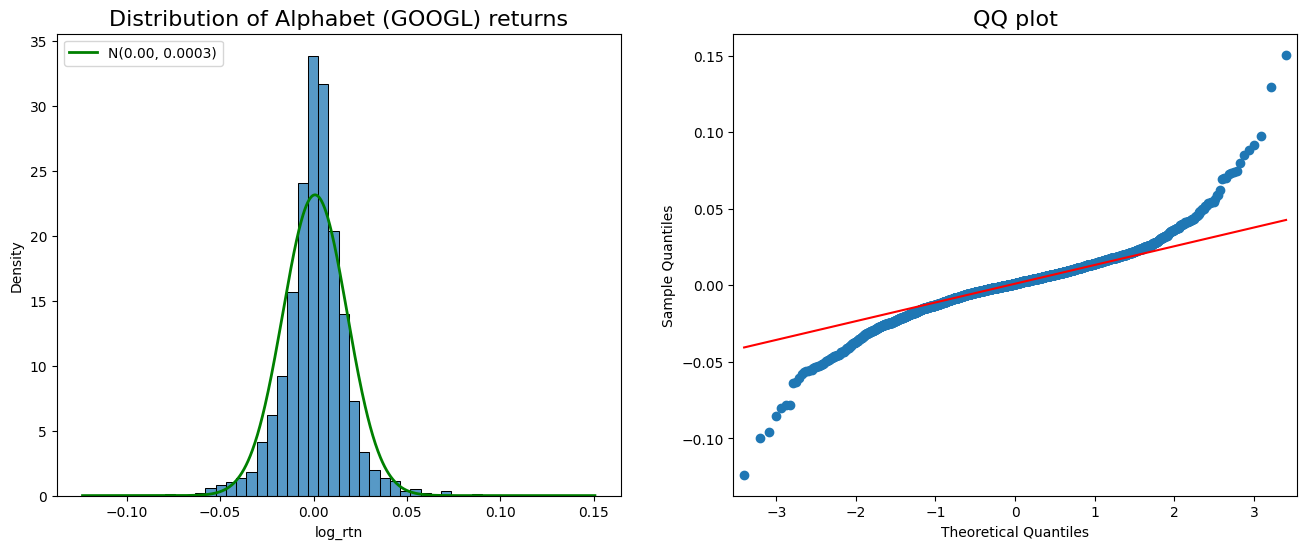

In [ ]:
# 결측값 제거
df = df.dropna(how='any')

# 정규 분포의 매개변수 정의
r_range = np.linspace(min(df.log_rtn), max(df.log_rtn), num=1000)
mu = df.log_rtn.mean()
sigma = df.log_rtn.std()
norm_pdf = scs.norm.pdf(r_range, loc=mu, scale=sigma)

# 로그 수익률 분포 시각화
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 로그 수익률 히스토그램
sns.histplot(df.log_rtn, kde=False, bins=50, stat="density", ax=ax[0])  # 구식 distplot 대신 histplot 사용
ax[0].set_title("Distribution of Alphabet (GOOGL) returns", fontsize=16)
ax[0].plot(r_range, norm_pdf, 'g', lw=2, label=f'N({mu:.2f}, {sigma**2:.4f})')
ax[0].legend(loc='upper left')

# Q-Q plot
qq = sm.qqplot(df.log_rtn.values, line='q', ax=ax[1])
ax[1].set_title("QQ plot", fontsize=16)

plt.show()



# Distribution of Alphabet (GOOGL) returns:

***- 양의왜도:***   분포의 오른쪽 꼬리가 왼쪽 꼬리보다 더 길다는 것을 의미합니다. 이는 특정 시점에서 주식이 급격한 긍정적인 변동을 보이지만, 부정적인 변동은 드물다는 것을 의미합니다.

***- 초과첨도:***  정규분포에 비해 두터운 꼬리와 피크분포가 있다. 이것은 정상 분포에 비해 더 많은 극단적인 값들(예: 큰 수익률 변동)이 있다는 것을 의미합니다.



# Q-Q plot:


데이터가 꼬리 부분에서 직선에서 벗어나고 있음을 알 수 있습니다. 이는 데이터가 정규분포에 비해 더 두꺼운 꼬리를 가지고 있으며, 더 많은 극단적인 값이 존재한다는 것을 의미합니다.

In [ ]:
import scipy.stats as scs

# Jarque-Bera тест на нормальность
jb_test = scs.jarque_bera(df['log_rtn'].values)

print('---------- Descriptive Statistics ----------')
print('Range of dates:', min(df.index.date), '-', max(df.index.date))
print('Number of observations:', df.shape[0])
print(f'Mean: {df["log_rtn"].mean():.4f}')
print(f'Median: {df["log_rtn"].median():.4f}')
print(f'Min: {df["log_rtn"].min():.4f}')
print(f'Max: {df["log_rtn"].max():.4f}')
print(f'Standard Deviation: {df["log_rtn"].std():.4f}')
print(f'Skewness: {df["log_rtn"].skew():.4f}')
print(f'Kurtosis: {df["log_rtn"].kurtosis():.4f}')
print(f'Jarque–Bera statistic: {jb_test[0]:.2f} with p-value: {jb_test[1]:.5f}')


---------- Descriptive Statistics ----------
Range of dates: 2013-01-03 - 2024-12-31
Number of observations: 3019
Mean: 0.0008
Median: 0.0011
Min: -0.1237
Max: 0.1506
Standard Deviation: 0.0172
Skewness: 0.1524
Kurtosis: 7.1317
Jarque–Bera statistic: 6384.82 with p-value: 0.00000



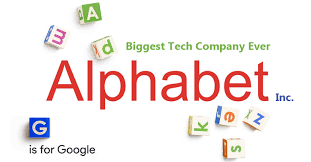


# 다음은 분석 결과에 대한 요약입니다:


1.   날짜 범위: 2013-01-03부터 2024-12-31까지 — 데이터는 약 12에 걸쳐 있다.
2.   관측치 수: 3019
3.   평균: 0.0008 — 평균적으로 로그 수익률은 0에 가까운 값으로, 장기적으로 수익률이 매우 낮은 경향이 있음을 나타냅니다.
4. 중앙값: 0.0011 — 중앙값이 평균보다 약간 높아, 수익률 분포에서 긍정적인 쏠림이 있음을 의미합니다.
5. 최소값: -0.1237 — 분석 기간 동안 가장 큰 하락폭으로, 시장에서 큰 하락이 있었음을 나타냅니다.
6. 최대값: 0.1506 — 가장 큰 상승폭을 나타내며, 시장에서 급격한 상승이 있었음을 나타냅니다.
 다른 말로 분석된 기간 동안 가장 큰 하락은 **12.37%**, 가장 큰 상승은 **15.06%**였습니다.

7. 표준편차 : 0.0172 — 중간 정도의 변동성을 나타내며, 수익률이 평균값에서 약 1.72% 정도 변동함을 의미합니다.
8. 비대칭도: 0.1524 — 약간의 양의 비대칭도를 나타내며, 이는 긍정적인 편향이 있다는 것을 의미합니다. 즉, 양의 수익률을 가진 데이터가 더 많습니다.
9. 첨도: 7.1317 — 3보다 훨씬 큰 값으로, 데이터의 분포가 두꺼운 꼬리를 가지고 있다는 것을 의미합니다. 이는 극단적인 변화가 정상 분포보다 자주 발생함을 나타냅니다.
이는 금융 시장에 많은 요인과 사건들이 영향을 미쳐 가격의 큰 변동을 일으킬 수 있다는 것이다. 이러한 극단적인 변화는 시장에서 정상적인 현상이며, 시장은 언제든지 예측할 수 없는 변화에 노출되어 있다는 것을 나타냅니다.
10. 자르크-베라 테스트:
통계량: 6384.82
p-값: 0.00000
이는 데이터가 정규분포를 따르지 않음을 나타냅니다. p-값이 매우 작기 때문에, 수익률 분포가 정규분포를 따른다는 가설을 기각합니다. 이는 금융 데이터에서 흔히 나타나는 특징으로, 극단적인 사건들(큰 하락이나 급격한 상승 등)이 정규분포에서 예상보다 더 자주 발생하기 때문입니다.



---


전체적으로, **GOOGL** 주식의 로그 수익률 분포는 정규 분포에서 크게 벗어나 있으며, 극단적인 사건들이 존재하는 것을 보여줍니다. 이는 정규성 테스트와 첨도 및 비대칭도 값이 높다는 결과에서 확인되며, 이는 가격 변화가 급격하게 일어나는 사건들이 금융 시장에서 흔히 발생한다는 것을 의미합니다.**주요 결론은 GOOGL **주식 시장이 다른 많은 금융 시장과 마찬가지로 정규 분포를 따르지 않는다는 것입니다. 이는 금융 시장에서 일반적인 특성으로, 가격의 급격한 변동, 즉 큰 상승이나 하락이 정규 분포가 예측하는 것보다 훨씬 더 자주 발생한다는 것을 나타냅니다. 이러한 현상은 경제적 사건, 뉴스, 규제 변화, 투자자 행동 등과 같은 예측할 수 없는 여러 요인의 영향을 받기 때문입니다. 이 요인들은 일반적인 경향을 벗어난 큰 변동을 일으키며, 금융 시장에서의 불확실성과 리스크를 증가시킵니다.


# 2.변동성 클러스터링 현상 확인하기

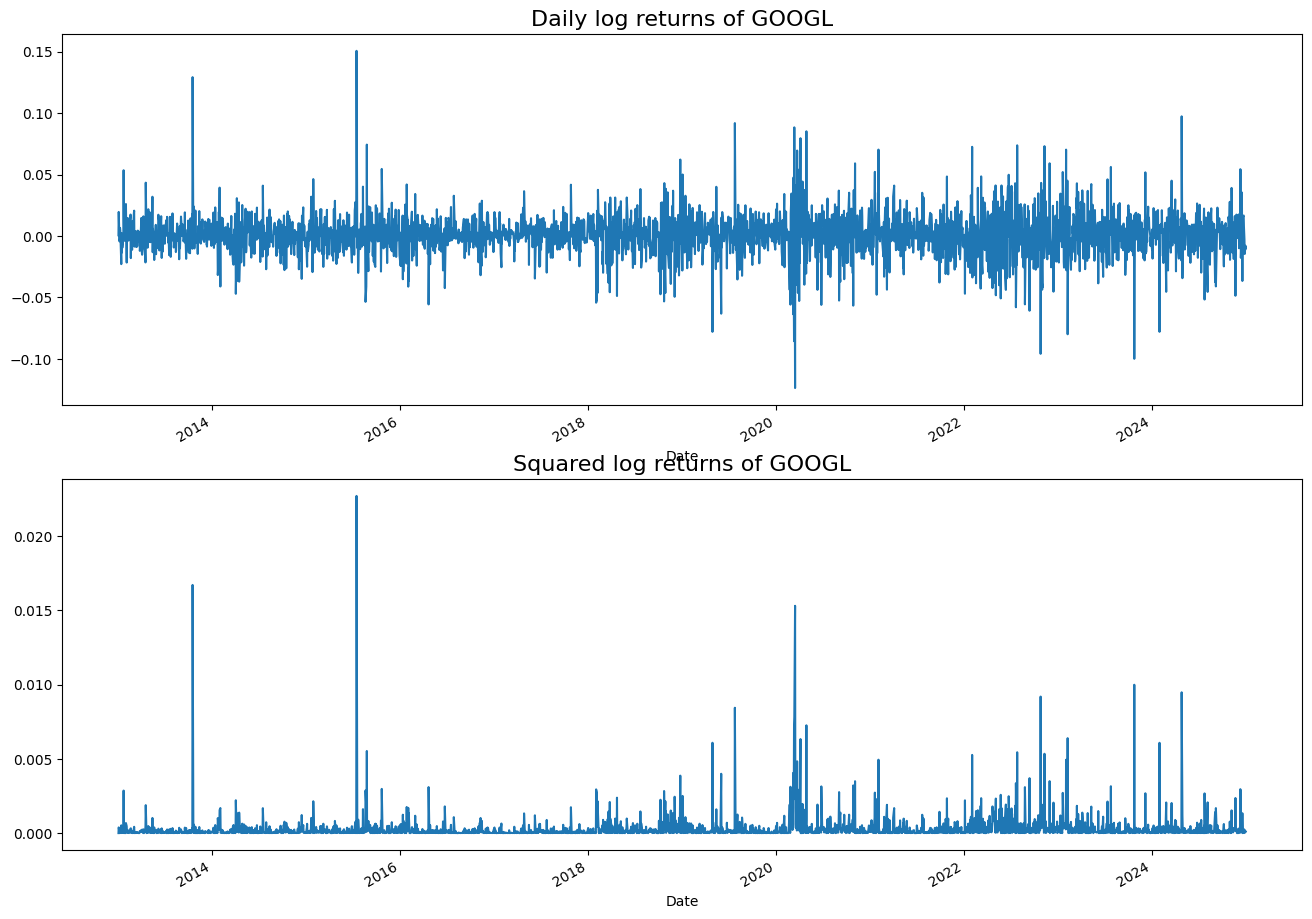

In [ ]:
# 그래프 그리기
fig, ax = plt.subplots(2, 1, figsize=(16, 12))

# 첫 번째 그래프: 일간 로그 수익률
df['log_rtn'].plot(ax=ax[0])
ax[0].set_title('Daily log returns of GOOGL', fontsize=16)

# 두 번째 그래프: 로그 수익률의 제곱
df['log_rtn'].pow(2).plot(ax=ax[1])
ax[1].set_title('Squared log returns of GOOGL', fontsize=16)

# 그래프 표시
plt.show()

## **Daily log returns of GOOGL**

첫 번째 그래프에서 수익률이 변동하지만 특정 시점(2015년, 2016년, 2020년 등)에서 급격한 상승이 발생하는 것을 볼 수 있습니다. 이는 변동성이 특정 기간에 집중될 수 있음을 의미하며, 이는 변동성 클러스터링 현상입니다.

## **Squared log returns of GOOGL**

두 번째 그래프에서도 변동성이 클러스터 내에 집중되는 것을 확인할 수 있습니다. 특히 급격한 수익률 변화가 일어나는 시점에서 더욱 두드러지며, 이는 일정 기간 동안 높은 변동성이 이어지고 그 후 낮은 변동성으로 돌아가는 현상을 보여줍니다.

# 결론
변동성 클러스터링 현상은 두 그래프 모두에서 확인되며, 데이터는 높은 변동성(로그 수익률의 제곱)을 일정 기간에 걸쳐 군집화되어 나타나며 이는 변동성 클러스터링 현상에 특징적입니다.



# **3.  자기상관성의 부재**

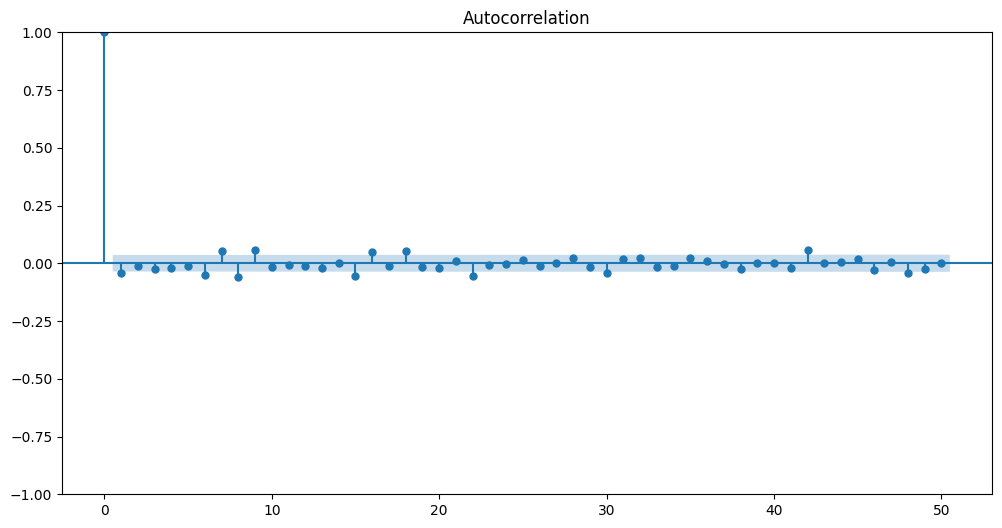

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
# 로그 수익률의 자기상관성 확인 (50개의 시차, 95% 신뢰 구간)
N_lags = 50
sig_level = 0.05

fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df['log_rtn'], lags=N_lags, alpha=sig_level, ax=ax)

plt.show()

### 로그 수익률의 자기상관 플롯은 지연 0에서의 자기상관이 1임을 보여줍니다. 이는 데이터가 자기 자신과 상관관계가 있음을 의미하므로 당연한 일입니다.  이는 로그 수익률이 자기상관되지 않음을 확인시켜 주며, 이는 시장이 무작위적으로 움직이고 있으며, 과거 수익률이 미래 수익률을 예측하지 못한다는 것을 의미합니다.

# **4. 로그 수익률 제곱에 대한 자기상관 존재 여부**

50개의과거제곱/ 절대로그수익률과현제곱/ 절대로그수익률과의상관관계확인-95% 신뢰구간으로도식화

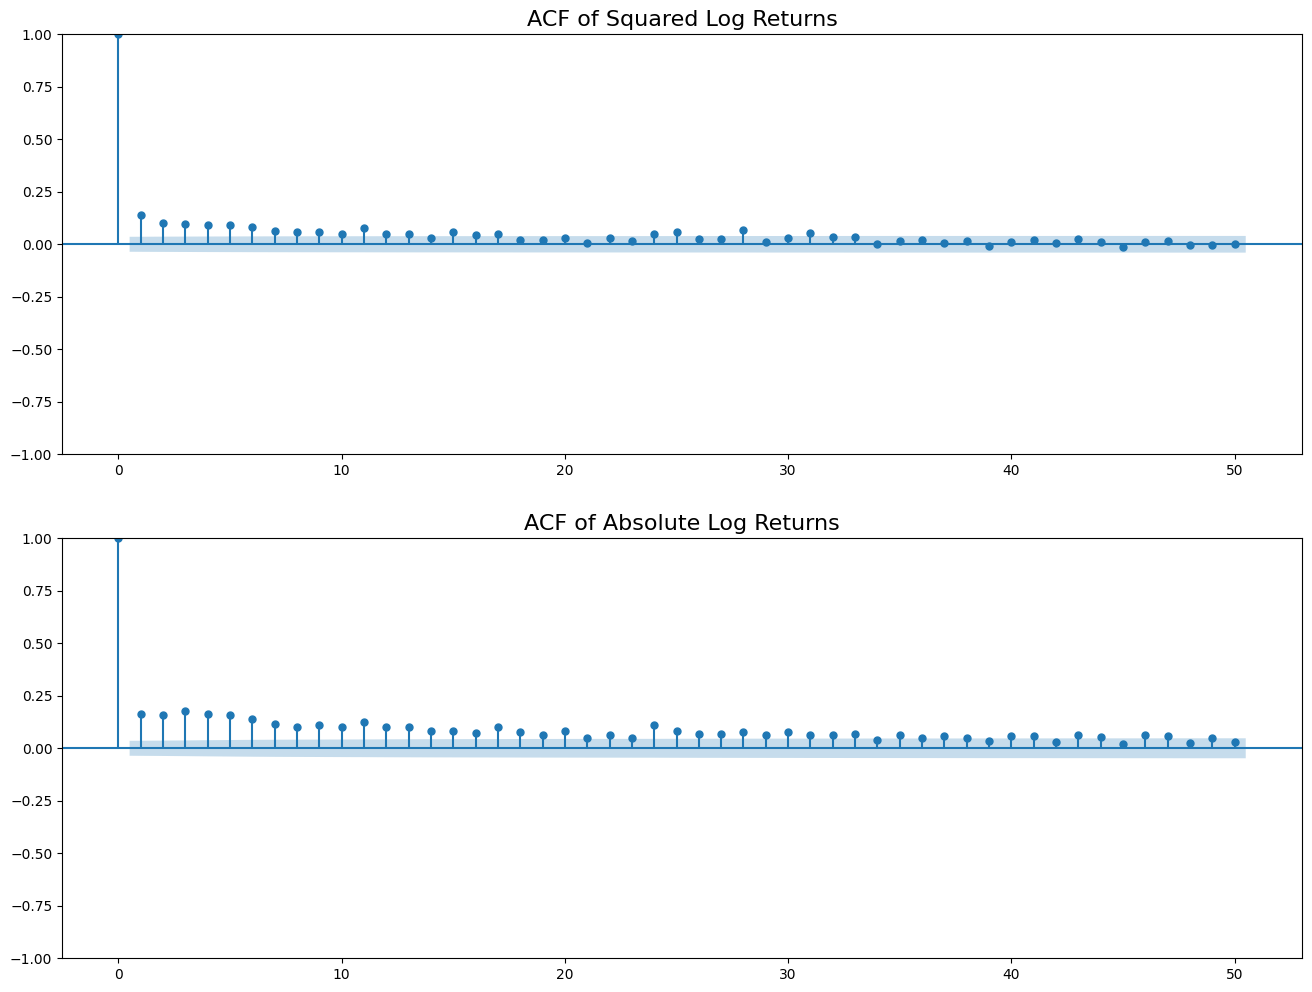

In [ ]:
# 자기상관을 위한 파라미터 설정
N_lags = 50
sig_level = 0.05

# 두 개의 그래프 그리기
fig, ax = plt.subplots(2, 1, figsize=(16, 12))

# 로그 수익률의 제곱에 대한 그래프
plot_acf(df['log_rtn'].pow(2), lags=N_lags, alpha=sig_level, ax=ax[0])
ax[0].set_title("ACF of Squared Log Returns", fontsize=16)

# 로그 수익률의 절댓값에 대한 그래프
plot_acf(np.abs(df['log_rtn']), lags=N_lags, alpha=sig_level, ax=ax[1])
ax[1].set_title("ACF of Absolute Log Returns", fontsize=16)

plt.show()

## *ACF of Squared Log Returns*
- 첫 번째 지연 후에 자기상관이 빠르게 감소하고 양의 수준에서 멈추고 몇 개의 지연에서 작은 의존성을 유지하는 것을 볼 수 있습니다.이는 **데이터의 변동성이 의존성**을 가지고 있음을 나타내며, 한 기간에서 높은 변동성이 발생하면 다음 기간에서도 높은 변동성이 지속될 가능성이 높다는 것을 의미합니다. 이러한 현상은 변동성 클러스터링을 확인시켜 줍니다. 즉, 높은 변동성 기간이 서로 그룹화된다는 것을 보여줍니다.

## *ACF of Absolute Log Returns*

두 번째 그래프에서도 유사한 패턴이 관찰됩니다. 자기상관이 다시 감소하지만 몇 개의 지연에서 의존성을 유지합니다.이는 수익률의 절댓값 변화도 시간에 따른 의존성이 있음을 나타내며 변동성 클러스터링을 확인시켜 줍니다.


## *결론*
- **변동성 클러스터링:** 두 개의 자기상관 그래프에서 변동성 클러스터링 현상이 확인되었습니다. 이는 높은 변동성 기간이 서로 연속적으로 발생하는 경향이 있으며, 낮은 변동성 기간 역시 그룹화되는 경향이 있다는 것을 의미합니다.

- **변동성 예측:** 자기상관 그래프에서 반복되는 패턴은 변동성이 급증한 후에는 계속해서 높은 변동성이 유지될 가능성이 있음을 시사합니다. 이는 헤지 전략을 만들거나 높은 변동성 기간을 바탕으로 자산의 행동을 예측하는 데 중요한 정보가 됩니다.

따라서, 데이터는 변동성에 대한 장기적인 의존성이 존재함을 시사하며, 이는 로그 수익률 제곱과 절댓값에 대한 자기상관을 통해 확인할 수 있습니다.








# Alphabet (Google) 회사의 데이터를 분석한 결과

시장은 수익률에 자가상관이 없지만 변동성에는 장기적인 의존성이 존재한다는 결론을 내릴 수 있습니다. 즉, Alphabet (Google)  회사의 로그 수익률은 이전 수익률에 따른 상관관계가 없으며, 이는 자가상관이 없다는 것을 의미합니다. 이는 과거의 가격 변화(또는 수익률)가 미래의 가격 변화나 수익률을 정확하게 예측하는 데 도움이 되지 않는다는 것을 의미합니다. 그러나 변동성에 대한 장기적인 의존성은 수익률에 자가상관이 없더라도 변동성(즉, 가격의 변동성 정도)이 이전 기간과 상관관계가 있을 수 있음을 나타냅니다.


### 변동성 클러스터링과 높은 변동성 기간은 리스크(위험을) 평가와 이 리스크를 관리하기 위한 전략 개발에서 중요한 역할을 합니다.이러한 결과는 변동성 모니터링의 중요성과 미래의 높은 변동성 또는 낮은 변동성 기간을 예측하기 위한 모델 활용의 중요성을 강조하며, 이는 투자자와 분석가에게 중요합니다.

